In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Load ratings
ratings = pd.read_csv('../data/u.data', 
                      sep='\t', 
                      names=['user_id', 'movie_id', 'rating', 'timestamp'])

# Load movies
movies = pd.read_csv('../data/u.item',
                     sep='|',
                     encoding='latin-1',
                     names=['movie_id', 'title', 'release_date', 'video_release', 
                            'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation',
                            'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
                            'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
                            'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'])

print("Data loaded! ✅")
print(f"Ratings: {len(ratings):,}")
print(f"Users: {ratings['user_id'].nunique()}")
print(f"Movies: {ratings['movie_id'].nunique()}")

Data loaded! ✅
Ratings: 100,000
Users: 943
Movies: 1682


In [2]:
# Encode user_id and movie_id to start from 0
# Neural networks need sequential indices starting from 0

user_ids = ratings['user_id'].unique()
movie_ids = ratings['movie_id'].unique()

# Create mapping dictionaries
user2idx = {user: idx for idx, user in enumerate(user_ids)}
movie2idx = {movie: idx for idx, movie in enumerate(movie_ids)}

# Apply mappings
ratings['user'] = ratings['user_id'].map(user2idx)
ratings['movie'] = ratings['movie_id'].map(movie2idx)

num_users = len(user_ids)
num_movies = len(movie_ids)

print(f"Number of users: {num_users}")
print(f"Number of movies: {num_movies}")
print(f"\nOriginal user_id example: {ratings['user_id'][0]}")
print(f"Encoded user index: {ratings['user'][0]}")
print(f"\nRatings sample:")
ratings[['user', 'movie', 'rating']].head()

Number of users: 943
Number of movies: 1682

Original user_id example: 196
Encoded user index: 0

Ratings sample:


,user,movie,rating
0,0,0,3
1,1,1,3
2,2,2,1
3,3,3,2
4,4,4,1


In [3]:
# Build collaborative filtering neural network
def build_model(num_users, num_movies, embedding_size=50):
    
    # User input and embedding
    user_input = keras.Input(shape=(1,), name='user_input')
    user_embedding = layers.Embedding(num_users, embedding_size, name='user_embedding')(user_input)
    user_vector = layers.Flatten(name='user_flatten')(user_embedding)
    
    # Movie input and embedding|
    movie_input = keras.Input(shape=(1,), name='movie_input')
    movie_embedding = layers.Embedding(num_movies, embedding_size, name='movie_embedding')(movie_input)
    movie_vector = layers.Flatten(name='movie_flatten')(movie_embedding)
    
    # Combine user and movie vectors
    concat = layers.Concatenate()([user_vector, movie_vector])
    
    # Dense layers
    dense1 = layers.Dense(128, activation='relu')(concat)
    dense2 = layers.Dense(64, activation='relu')(dense1)
    dense3 = layers.Dense(32, activation='relu')(dense2)
    
    # Output — single rating prediction
    output = layers.Dense(1, activation='sigmoid')(dense3)
    
    model = keras.Model(inputs=[user_input, movie_input], outputs=output)
    
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    
    return model

# Build it
model = build_model(num_users, num_movies)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ user_input (InputLayer)       │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ movie_input (InputLayer)      │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ user_embedding (Embedding)    │ (None, 1, 50)             │          47,150 │ user_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ movie_embedding (Embedding)   │ (None, 1, 50)             │          84,100 │ movie_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ user_flatten (Flatten)        │ (None, 50)                │               0 │ user_embedding[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ movie_flatten (Flatten)       │ (None, 50)                │               0 │ movie_embedding[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 100)               │               0 │ user_flatten[0][0],        │
│                               │                           │                 │ movie_flatten[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │          12,928 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           8,256 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │           2,080 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 1)                 │              33 │ dense_2[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 154,547 (603.70 KB)

 Trainable params: 154,547 (603.70 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Normalize ratings to 0-1 range
ratings['rating_normalized'] = ratings['rating'] / 5.0

# Split into train and test sets
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

# Prepare inputs
x_train = [train['user'].values, train['movie'].values]
y_train = train['rating_normalized'].values

x_test = [test['user'].values, test['movie'].values]
y_test = test['rating_normalized'].values

In [6]:
# Train the model
history = model.fit(
    x_train,      # [user indices, movie indices]
    y_train,      # normalized ratings
    epochs=10,    # go through training data 10 times
    batch_size=64,
    validation_data=(x_test, y_test),
    verbose=1
)

print("Training complete! ✅")

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.0388 - mae: 0.1569 - val_loss: 0.0359 - val_mae: 0.1491
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 0.0344 - mae: 0.1465 - val_loss: 0.0350 - val_mae: 0.1490
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.0326 - mae: 0.1425 - val_loss: 0.0344 - val_mae: 0.1465
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0304 - mae: 0.1371 - val_loss: 0.0346 - val_mae: 0.1457
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0278 - mae: 0.1309 - val_loss: 0.0354 - val_mae: 0.1466
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0252 - mae: 0.1243 - val_loss: 0.0357 - val_mae: 0.1483
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0226 - mae: 0.1175 - val_loss: 0.0370 - val_mae: 0.1501
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0204 - mae: 0.1116 - val_loss: 0.0382 - val_mae: 0.1517
Epoch 9/10
1250/1250 ━━━━━━━━━━━━

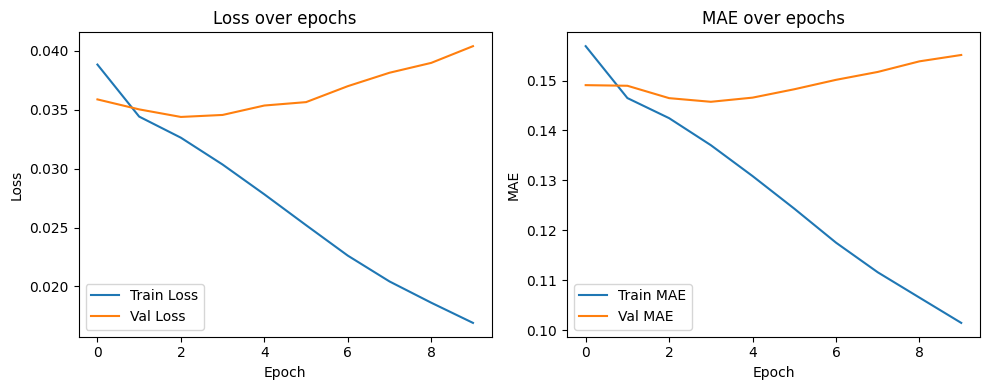

Best val_loss at epoch: 3
Best val_mae: 0.1457
In stars: 0.73 stars average error


In [7]:
# Plot training vs validation loss
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('MAE over epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Best val_loss at epoch: {history.history['val_loss'].index(min(history.history['val_loss'])) + 1}")
print(f"Best val_mae: {min(history.history['val_mae']):.4f}")
print(f"In stars: {min(history.history['val_mae']) * 5:.2f} stars average error")

In [8]:
# Rebuild model with dropout to prevent overfitting
def build_model_v2(num_users, num_movies, embedding_size=50):
    
    user_input = keras.Input(shape=(1,), name='user_input')
    user_embedding = layers.Embedding(num_users, embedding_size)(user_input)
    user_vector = layers.Flatten()(user_embedding)
    
    movie_input = keras.Input(shape=(1,), name='movie_input')
    movie_embedding = layers.Embedding(num_movies, embedding_size)(movie_input)
    movie_vector = layers.Flatten()(movie_embedding)
    
    concat = layers.Concatenate()([user_vector, movie_vector])
    
    dense1 = layers.Dense(128, activation='relu')(concat)
    dropout1 = layers.Dropout(0.3)(dense1)        # ← NEW
    dense2 = layers.Dense(64, activation='relu')(dropout1)
    dropout2 = layers.Dropout(0.3)(dense2)         # ← NEW
    dense3 = layers.Dense(32, activation='relu')(dropout2)
    output = layers.Dense(1, activation='sigmoid')(dense3)
    
    model = keras.Model(inputs=[user_input, movie_input], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model_v2 = build_model_v2(num_users, num_movies)
print("Model v2 built! ✅")

Model v2 built! ✅


In [9]:
model_v2.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.0397 - mae: 0.1589 - val_loss: 0.0360 - val_mae: 0.1518
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 0.0351 - mae: 0.1484 - val_loss: 0.0350 - val_mae: 0.1481
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0338 - mae: 0.1457 - val_loss: 0.0347 - val_mae: 0.1473
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0323 - mae: 0.1421 - val_loss: 0.0344 - val_mae: 0.1477
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0307 - mae: 0.1381 - val_loss: 0.0343 - val_mae: 0.1459


In [10]:
def get_recommendations(user_id, model, ratings, movies, n=10):
    
    # Get movies this user already rated
    watched = ratings[ratings['user_id'] == user_id]['movie_id'].values
    
    # Get all movies they haven't seen
    all_movies = ratings['movie_id'].unique()
    unseen = [m for m in all_movies if m not in watched]
    
    # Encode user
    user_idx = user2idx[user_id]
    user_array = np.array([user_idx] * len(unseen))
    
    # Encode unseen movies
    movie_array = np.array([movie2idx[m] for m in unseen])
    
    # Predict ratings
    predictions = model_v2.predict([user_array, movie_array], verbose=0)
    predictions = predictions.flatten() * 5  # denormalize
    
    # Get top N
    top_idx = predictions.argsort()[-n:][::-1]
    top_movies = [unseen[i] for i in top_idx]
    top_ratings = [predictions[i] for i in top_idx]
    
    # Get titles
    results = pd.DataFrame({'movie_id': top_movies, 'predicted_rating': top_ratings})
    results = results.merge(movies[['movie_id', 'title']], on='movie_id')
    
    return results[['title', 'predicted_rating']]

# Test it — get recommendations for user 1
recommendations = get_recommendations(1, model_v2, ratings, movies)
print("Top 10 recommendations for User 1:")
print(recommendations.to_string(index=False))

Top 10 recommendations for User 1:
                                                      title  predicted_rating
                                          Casablanca (1942)          4.773106
                                      Close Shave, A (1995)          4.767285
                                    Schindler's List (1993)          4.761067
                                     Pather Panchali (1955)          4.760277
Paradise Lost: The Child Murders at Robin Hood Hills (1996)          4.758563
                     One Flew Over the Cuckoo's Nest (1975)          4.745144
                                         Rear Window (1954)          4.722133
                                  Lawrence of Arabia (1962)          4.707370
                                               Faust (1994)          4.699323
                                                Anna (1996)          4.687314


In [11]:
user1_ratings = ratings[ratings['user_id'] == 1].merge(
    movies[['movie_id', 'title']], on='movie_id'
)
user1_ratings = user1_ratings.sort_values('rating', ascending=False)
print("What User 1 actually rated highly:")
print(user1_ratings[['title', 'rating']].head(10).to_string(index=False))

What User 1 actually rated highly:
                                                 title  rating
                             Back to the Future (1985)       5
                        When Harry Met Sally... (1989)       5
                       Nikita (La Femme Nikita) (1990)       5
                             Three Colors: Blue (1993)       5
                                      Lone Star (1996)       5
                             Breaking the Waves (1996)       5
                               Jean de Florette (1986)       5
                      Shawshank Redemption, The (1994)       5
Wallace & Gromit: The Best of Aardman Animation (1996)       5
                   Star Trek: The Wrath of Khan (1982)       5
